In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset

df = pd.read_csv("fraudTest.csv")

# Display first 5 rows
df.head()

,sn,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,21-06-2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,21-06-2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,21-06-2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",21-10-1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,21-06-2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,25-07-1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,21-06-2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,06-07-1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [3]:
df.dtypes

sn                         int64
trans_date_trans_time        str
cc_num                   float64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [4]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df.dtypes

C:\Users\kemo7\AppData\Local\Temp\ipykernel_16240\1967565742.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])


sn                                int64
trans_date_trans_time    datetime64[us]
cc_num                          float64
merchant                            str
category                            str
amt                             float64
first                               str
last                                str
gender                              str
street                              str
city                                str
state                               str
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                                 str
dob                                 str
trans_num                           str
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object

In [5]:
df.isna().sum()

sn                       0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [8]:
df[['amt', 'merch_long']].head()

,amt,merch_long
0,2.86,-81.200714
1,29.84,-109.960431
2,41.28,-74.196111
3,60.05,-80.883061
4,3.19,-85.884734


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['amt', 'merch_long']].copy()

df_scaled[['amt', 'merch_long']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,amt,merch_long
0,0.000082,0.857112
1,0.001267,0.568706
2,0.001769,0.927355
3,0.002594,0.860298
4,0.000096,0.810140


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['amt', 'merch_long']].copy()

df_standardized[['amt', 'merch_long']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,amt,merch_long
0,-0.424463,0.657586
1,-0.252337,-1.436610
2,-0.179353,1.167640
3,-0.059605,0.680717
4,-0.422358,0.316510


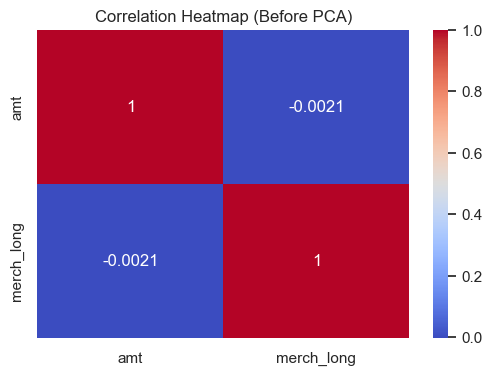

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['amt','merch_long']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [13]:
from sklearn.decomposition import PCA

X = df_standardized[['amt', 'merch_long']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50102629 0.49897371]


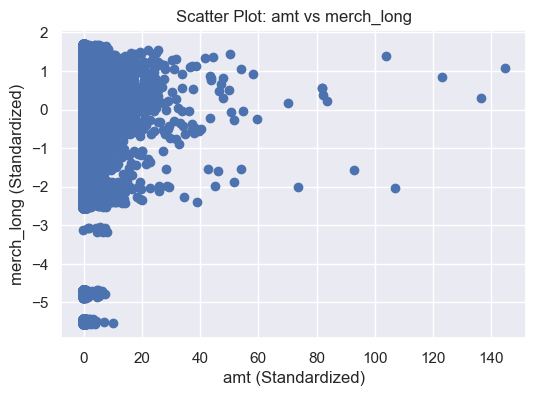

In [15]:
 plt.figure(figsize=(6,4))
 plt.scatter(df_standardized['amt'], df_standardized['merch_long'])
 plt.xlabel("amt (Standardized)")
 plt.ylabel("merch_long (Standardized)")
 plt.title("Scatter Plot: amt vs merch_long")
 plt.show()

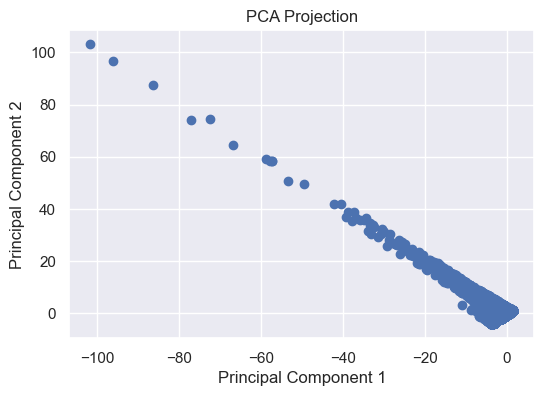

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()